# `diffusion_lib` — Use Cases

**Authors:** Iván Domínguez Hernández · Lucas Miranda López  
**Tutor:** Alberto Suárez González  
**Course:** Aprendizaje Automático III — Grado en Ciencia e Ingeniería de Datos, UAM

---

This notebook walks through **all five use cases** of the `diffusion_lib` package.
Each section maps directly to a use case from the Software Design chapter:

| # | Use Case | Key components |
|---|---|---|
| CU-01 | **Score model training** | `DiffusionModel`, `VEProcess`/`VPProcess`, `UNet` |
| CU-02 | **Unconditional generation** | `EulerMaruyama`, `PredictorCorrector`, `ProbabilityFlowODE` |
| CU-03 | **Class-conditioned synthesis (CFG)** | `ConditionalUNet`, `CFGWrapper` |
| CU-04 | **Inpainting** | `ImputationSampler` |
| CU-05 | **Quality evaluation** | `BPDEvaluator`, `FIDISEvaluator` |


---
## 0 · Environment Setup

Install `diffusion_lib` and its dependencies before running any section.


In [1]:
# !pip install -e .              # from repo root
# !pip install torch torchvision numpy matplotlib tqdm


In [2]:
import torch
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from diffusion_lib import (
    VEProcess, VPProcess,
    LinearSchedule, CosineSchedule, ExponentialSchedule,
    UNetScoreModelColor as UnconditionalUNet,
    CondUNetScoreModel  as ConditionalUNet,
    CFGWrapper,
    EulerMaruyamaSampler, PredictorCorrectorSampler, ProbabilityFlowODESampler,
    ImputationSampler,
    GenerativeDiffusionModel as DiffusionModel,
    compute_bpd,
)
from diffusion_lib.metrics.fid_is import compute_fid, compute_is

DEVICE = 'mps'
print(f'Running on: {DEVICE}')

Running on: mps


In [3]:
# Global hyper-parameters
IMG_SIZE   = 32
CHANNELS   = 3
T_STEPS    = 1000
BATCH_SIZE = 128
CKPT_DIR   = Path('checkpoints')
CKPT_DIR.mkdir(exist_ok=True)

print(f'Image size : {IMG_SIZE}x{IMG_SIZE}x{CHANNELS}')
print(f'Time steps : {T_STEPS}')


Image size : 32x32x3
Time steps : 1000


---
## CU-01 · Score Model Training

**Goal:** configure a diffusion process (VE or VP), instantiate a U-Net score model, and run the denoising score-matching training loop.

At each training iteration $t \sim \mathcal{U}\{1,\ldots,T\}$:
1. **Forward process** injects Gaussian noise into $\mathbf{x}_0$.
2. The U-Net predicts the injected noise $\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)$.
3. **Score-matching loss** is minimised:
$$\mathcal{L}(\theta)=\mathbb{E}_{t,\mathbf{x}_0,\boldsymbol{\epsilon}}\bigl[\|\boldsymbol{\epsilon}_\theta(\mathbf{x}_t,t)-\boldsymbol{\epsilon}\|_2^2\bigr]$$


In [4]:
# 1.1  Dataset (SVHN — Street View House Numbers, 32×32 RGB, 10 digit classes)
transform = T.Compose([
    T.ToTensor(),
    T.Normalize([0.5]*CHANNELS, [0.5]*CHANNELS),
])
train_dataset = torchvision.datasets.SVHN(
    root='./data', split='train', download=True, transform=transform
)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True
)
print(f'Training samples: {len(train_dataset):,}  |  Batches/epoch: {len(train_loader)}')

Training samples: 73,257  |  Batches/epoch: 573


In [5]:
# 1.2a  Variance Exploding (VE) process
#   Forward:   dx = σ^t dW
#   Marginal:  x_t | x_0 ~ N(x_0, σ_t² I),  σ_t² = (σ^{2t} − 1) / (2 ln σ)
ve_process = VEProcess(sigma=25.0, T=1.0)
print(f'VE process  |  sigma={ve_process.sigma}  T={ve_process.T}')

VE process  |  sigma=25.0  T=1.0


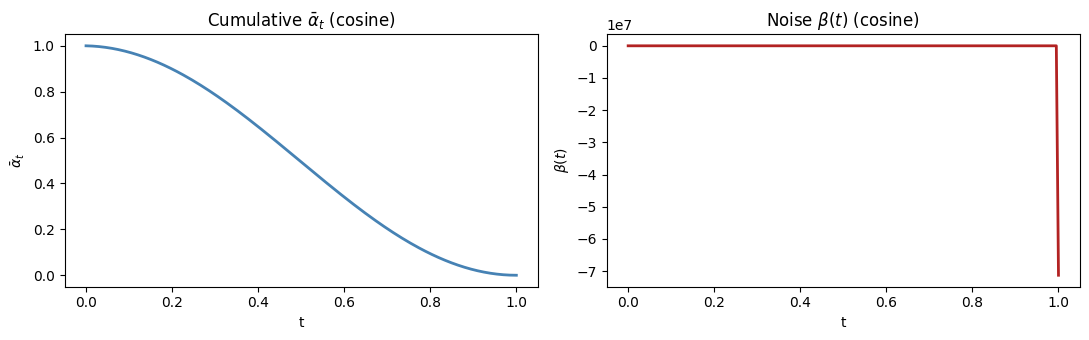

beta_min=-71300848.0000  beta_max=20.0000


In [6]:
# 1.2b  Variance Preserving (VP) process with cosine schedule
#   Forward (Ornstein-Uhlenbeck):
#     dx = −½ β(t) x dt + √β(t) dW
#
#   Cosine schedule avoids premature noise saturation at low resolution
#   (Nichol & Dhariwal 2021).
cosine_schedule = CosineSchedule(s=0.008)
vp_process      = VPProcess(schedule=cosine_schedule, T=1.0)

# Visualise schedule  (t ∈ [0, 1] is the continuous diffusion time)
t_range = torch.linspace(0, 1, 200)
alphas  = cosine_schedule.alpha_bar(t_range).cpu().numpy()
betas   = cosine_schedule.beta(t_range).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(t_range, alphas, color='steelblue', lw=2)
axes[0].set_title(r'Cumulative $\bar\alpha_t$ (cosine)')
axes[0].set_xlabel('t'); axes[0].set_ylabel(r'$\bar\alpha_t$')
axes[1].plot(t_range, betas, color='firebrick', lw=2)
axes[1].set_title(r'Noise $\beta(t)$ (cosine)')
axes[1].set_xlabel('t'); axes[1].set_ylabel(r'$\beta(t)$')
plt.tight_layout(); plt.show()
print(f'beta_min={betas.min():.4f}  beta_max={betas.max():.4f}')

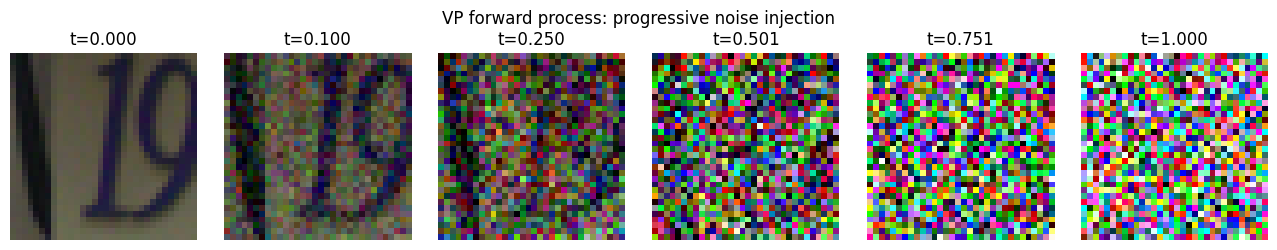

In [7]:
# 1.3  Visualise the forward process (noise injection)
#   Integer step indices are mapped to continuous time t ∈ [0, 1].
sample_img = train_dataset[0][0].unsqueeze(0).to(DEVICE)
timesteps  = [0, 100, 250, 500, 750, 999]

fig, axes = plt.subplots(1, len(timesteps), figsize=(13, 2.5))
for ax, t_idx in zip(axes, timesteps):
    t_float  = t_idx / (T_STEPS - 1)
    t_tensor = torch.tensor([t_float], device=DEVICE)
    noisy, _ = vp_process.perturb(sample_img, t_tensor)
    ax.imshow(noisy[0].permute(1,2,0).cpu().clamp(-1,1).numpy()*0.5+0.5)
    ax.set_title(f't={t_float:.3f}'); ax.axis('off')

fig.suptitle('VP forward process: progressive noise injection', fontsize=12)
plt.tight_layout(); plt.show()

In [8]:
# 1.4  U-Net score model (RF-02)
#   - 3-channel 32×32 images (SVHN)
#   - Gaussian random Fourier features for time embedding
#   - Skip connections in U-Net encoder/decoder
score_model = UnconditionalUNet(
    marginal_prob_std=vp_process.sigma_t,
    channels=[32, 64, 128, 256],
    embed_dim=256,
).to(DEVICE)

print(f'UnconditionalUNet  |  Parameters: {sum(p.numel() for p in score_model.parameters()):,}')

UnconditionalUNet  |  Parameters: 1,117,152


In [9]:
# 1.5  DiffusionModel: integrates process + sampler + score model  (RF-01)
model = DiffusionModel(
    process=vp_process,
    sampler=EulerMaruyamaSampler(),
    score_model=score_model,
    device=DEVICE,
)
print(f'Process : {model.process.__class__.__name__}')
print(f'Sampler : {model.sampler.__class__.__name__}')
print(f'Device  : {model.device}')

Process : VPProcess
Sampler : EulerMaruyamaSampler
Device  : mps


In [10]:
# 1.6  Training loop (RF-06)
NUM_EPOCHS    = 3       # set to 500+ for production quality
LEARNING_RATE = 2e-4

optimiser    = torch.optim.Adam(model.score_model.parameters(), lr=LEARNING_RATE)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimiser, T_max=NUM_EPOCHS * len(train_loader)
)
train_losses = []

for epoch in range(1, NUM_EPOCHS + 1):
    model.score_model.train()
    epoch_loss = 0.0
    for x_batch, _ in train_loader:
        loss = model.compute_loss(x_batch)
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()
        lr_scheduler.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f'Epoch {epoch:>3}/{NUM_EPOCHS}  |  loss: {avg_loss:.5f}')

# Save demo checkpoint under a distinct name so the production checkpoint
# (vp_cosine_uncond.pt, used by sections 2–5) is never overwritten.
ckpt_path = CKPT_DIR / 'vp_cosine_uncond_demo.pt'
torch.save(model.score_model.state_dict(), ckpt_path)
print(f'Demo checkpoint saved -> {ckpt_path}')

/Users/ivandominguez/Desktop/practicas3segundocuatri/apaut3/proyecto/proyecto_AAIII_02_diffusion_models/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch   1/3  |  loss: 1112.57916
Epoch   2/3  |  loss: 257.45135
Epoch   3/3  |  loss: 213.58012
Demo checkpoint saved -> checkpoints/vp_cosine_uncond_demo.pt


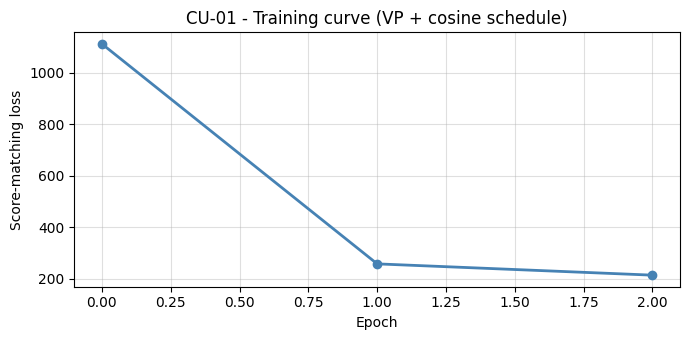

In [11]:
# 1.7  Training loss curve
plt.figure(figsize=(7, 3.5))
plt.plot(train_losses, marker='o', lw=2, color='steelblue')
plt.xlabel('Epoch'); plt.ylabel('Score-matching loss')
plt.title('CU-01 - Training curve (VP + cosine schedule)')
plt.grid(alpha=0.4); plt.tight_layout(); plt.show()


---
## CU-02 · Unconditional Image Generation

**Goal:** synthesise new images by integrating the **backward SDE / ODE** from pure Gaussian noise.

Three samplers are compared (RF-07):

| Sampler | Stochastic | Evals/step | BPD | Quality at low N |
|---|---|---|---|---|
| Euler-Maruyama | Yes | 1 | No | Low |
| Predictor-Corrector | Yes | M+1 | No | Medium-High |
| Probability Flow ODE | No | 1 | Yes | Medium* |

Backward VP SDE (Euler-Maruyama discretisation):
$$\mathbf{x}_{t-1}=\mathbf{x}_t+\left[\tfrac{1}{2}\beta(t)\mathbf{x}_t+\beta(t)\nabla_{\mathbf{x}}\log p_t\right]\Delta t+\sqrt{\beta(t)\Delta t}\,\mathbf{z}_t$$


In [12]:
# 2.1  Load checkpoint
state = torch.load(CKPT_DIR / 'vp_cosine_uncond.pt', map_location=DEVICE)
model.score_model.load_state_dict(state)
model.score_model.eval()
print('Checkpoint loaded.')

Checkpoint loaded.


In [13]:
# 2.2  Euler-Maruyama sampler
em_sampler = EulerMaruyamaSampler()

with torch.no_grad():
    samples_em = em_sampler.sample(
        score_model=model.score_model, process=vp_process,
        n_images=16, img_shape=(CHANNELS, IMG_SIZE, IMG_SIZE),
        n_steps=500, device=DEVICE,
    )

print(f'EM samples: {samples_em.shape}')

EM samples: torch.Size([16, 3, 32, 32])


In [14]:
# 2.3  Predictor-Corrector sampler
pc_sampler = PredictorCorrectorSampler(n_corrector_steps=1, snr=0.16)

with torch.no_grad():
    samples_pc = pc_sampler.sample(
        score_model=model.score_model, process=vp_process,
        n_images=16, img_shape=(CHANNELS, IMG_SIZE, IMG_SIZE),
        n_steps=500, device=DEVICE,
    )

print(f'PC samples: {samples_pc.shape}')

PC samples: torch.Size([16, 3, 32, 32])


In [15]:
# 2.4  Probability Flow ODE sampler
ode_sampler = ProbabilityFlowODESampler()

with torch.no_grad():
    samples_ode = ode_sampler.sample(
        score_model=model.score_model, process=vp_process,
        n_images=16, img_shape=(CHANNELS, IMG_SIZE, IMG_SIZE),
        n_steps=500, device=DEVICE,
    )

print(f'ODE samples: {samples_ode.shape}')

ODE samples: torch.Size([16, 3, 32, 32])


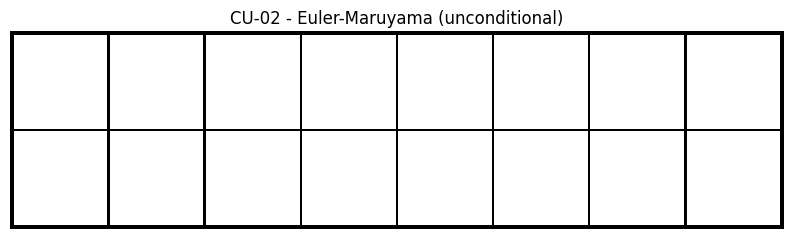

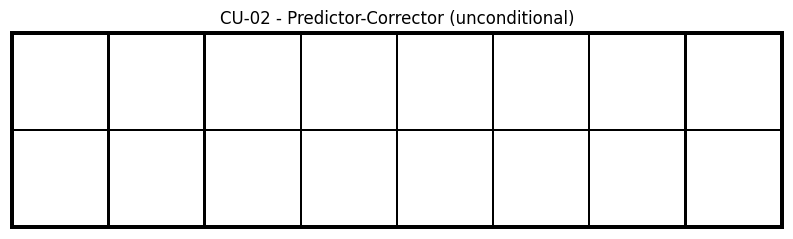

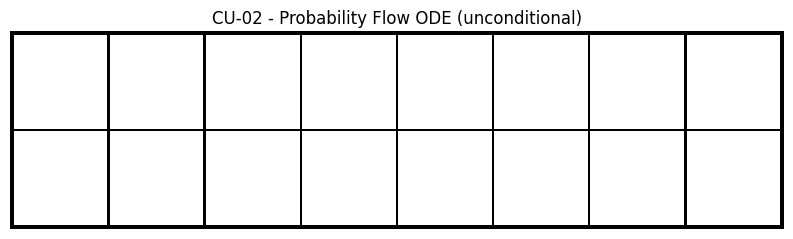

In [16]:
# 2.5  Visual comparison
def show_grid(tensor, title, nrow=8):
    imgs = (tensor.clamp(-1, 1) * 0.5 + 0.5).cpu()
    grid = torchvision.utils.make_grid(imgs, nrow=nrow, padding=2)
    plt.figure(figsize=(10, 2.5))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.title(title, fontsize=12); plt.axis('off')
    plt.tight_layout(); plt.show()

show_grid(samples_em,  'CU-02 - Euler-Maruyama (unconditional)')
show_grid(samples_pc,  'CU-02 - Predictor-Corrector (unconditional)')
show_grid(samples_ode, 'CU-02 - Probability Flow ODE (unconditional)')


---
## CU-03 · Class-Conditioned Synthesis (Classifier-Free Guidance)

**Goal:** generate images of a specific class using Classifier-Free Guidance (CFG).

### Mechanism (Ho & Salimans 2022)

One model is trained for both conditional and unconditional prediction.  
At inference the effective score is extrapolated:
$$\tilde{\boldsymbol{\epsilon}}_\theta(\mathbf{x}_t,t\mid y)=\boldsymbol{\epsilon}_\theta(\mathbf{x}_t,t\mid\emptyset)+w\bigl[\boldsymbol{\epsilon}_\theta(\mathbf{x}_t,t\mid y)-\boldsymbol{\epsilon}_\theta(\mathbf{x}_t,t\mid\emptyset)\bigr]$$

$w\in[1,10]$: higher $w$ improves class fidelity at the cost of diversity.


In [17]:
# 3.1  Conditional U-Net (RF-02, RF-08)
NUM_CLASSES = 10

cond_score_model = ConditionalUNet(
    marginal_prob_std=vp_process.sigma_t,
    n_classes=NUM_CLASSES,
    channels=[32, 64, 128, 256],
    embed_dim=256,
).to(DEVICE)

print(f'ConditionalUNet  |  Parameters: {sum(p.numel() for p in cond_score_model.parameters()):,}')
print(f'Null token index: {cond_score_model.null_token}  (unconditional branch)')

ConditionalUNet  |  Parameters: 1,251,552
Null token index: 10  (unconditional branch)


In [18]:
# 3.2  CFGWrapper is created per-class at inference (class_label baked in).
#   Training uses cond_score_model directly with random label dropout.
#   Guided score:  s̃ = s_uncond + w * (s_cond − s_uncond)
GUIDANCE_SCALE = 7.5

cond_model = DiffusionModel(
    process=vp_process,
    sampler=PredictorCorrectorSampler(n_corrector_steps=1, snr=0.16),
    score_model=cond_score_model,
    device=DEVICE,
)
print(f'Conditional DiffusionModel ready.  guidance_scale = {GUIDANCE_SCALE}')

Conditional DiffusionModel ready.  guidance_scale = 7.5


In [19]:
# 3.3  Train conditional model with CFG label dropout (RF-06, RF-08)
NUM_EPOCHS_COND = 3
UNCOND_PROB     = 0.1
opt_cond        = torch.optim.Adam(cond_score_model.parameters(), lr=2e-4)
cond_losses     = []

for epoch in range(1, NUM_EPOCHS_COND + 1):
    cond_score_model.train()
    epoch_loss = 0.0
    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        drop = torch.rand(y_batch.shape[0], device=DEVICE) < UNCOND_PROB
        y_batch = y_batch.clone()
        y_batch[drop] = cond_score_model.null_token

        t = torch.rand(x_batch.shape[0], device=DEVICE) * (1.0 - 1e-5) + 1e-5
        x_t, noise = vp_process.perturb(x_batch, t)

        view_shape = [x_batch.shape[0]] + [1] * (x_batch.dim() - 1)
        sigma = vp_process.sigma_t(t.view(*view_shape))

        score = cond_score_model(x_t, t, class_label=y_batch)
        loss  = torch.sum((sigma * score + noise) ** 2,
                          dim=list(range(1, x_batch.dim()))).mean()

        opt_cond.zero_grad()
        loss.backward()
        opt_cond.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    cond_losses.append(avg_loss)
    print(f'Epoch {epoch}/{NUM_EPOCHS_COND}  |  cond loss: {avg_loss:.5f}')

# Save demo checkpoint under a distinct name; production checkpoint
# (vp_cosine_cond_cfg.pt, loaded in section 3.4) is never overwritten.
torch.save(cond_score_model.state_dict(), CKPT_DIR / 'vp_cosine_cond_demo.pt')
print(f"Demo checkpoint saved -> {CKPT_DIR / 'vp_cosine_cond_demo.pt'}")
ckpt_cond = CKPT_DIR / 'vp_cosine_cond_cfg.pt'  # production model

KeyboardInterrupt: 

In [ ]:
# 3.4  Guided generation for all 10 SVHN digit classes (0–9)
SVHN_CLASSES = ['0','1','2','3','4','5','6','7','8','9']

state = torch.load(ckpt_cond, map_location=DEVICE)
cond_score_model.load_state_dict(state)
cond_score_model.eval()

cfg_gen_sampler = EulerMaruyamaSampler()
N_PER_CLASS = 4
all_cond = []

with torch.no_grad():
    for cls in range(NUM_CLASSES):
        cfg_wrapper = CFGWrapper(
            model=cond_score_model, class_label=cls, cfg_scale=GUIDANCE_SCALE,
        )
        samples = cfg_gen_sampler.sample(
            score_model=cfg_wrapper, process=vp_process,
            n_images=N_PER_CLASS, img_shape=(CHANNELS, IMG_SIZE, IMG_SIZE),
            n_steps=500, device=DEVICE,
        )
        all_cond.append(samples)

all_cond = torch.cat(all_cond, dim=0)
print(f'Generated {all_cond.shape[0]} conditioned images ({N_PER_CLASS} per class).')

Generated 40 conditioned images (4 per class).


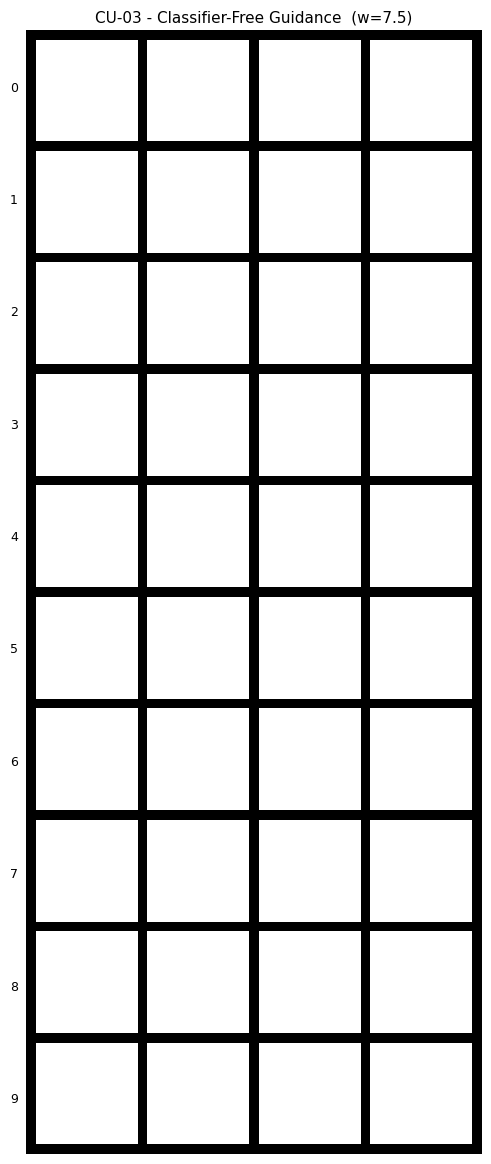

In [ ]:
# 3.5  Visualise per-class samples
imgs = (all_cond.clamp(-1, 1) * 0.5 + 0.5).cpu()
grid = torchvision.utils.make_grid(imgs, nrow=N_PER_CLASS, padding=3)

fig, ax = plt.subplots(figsize=(5, 14))
ax.imshow(grid.permute(1, 2, 0).numpy())
ax.set_title('CU-03 - Classifier-Free Guidance  (w=7.5)', fontsize=11)
ax.axis('off')
cell_h = grid.shape[1] / NUM_CLASSES
for i, name in enumerate(SVHN_CLASSES):
    ax.text(-3, (i+0.5)*cell_h, name, va='center', ha='right', fontsize=9)
plt.tight_layout(); plt.show()

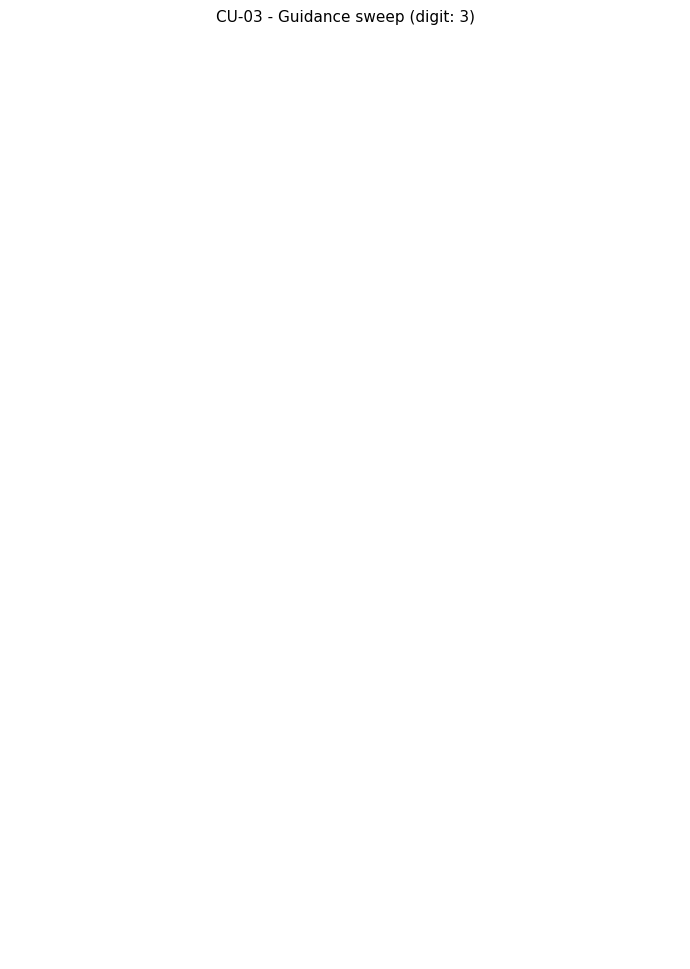

In [ ]:
# 3.6  Guidance scale sweep on digit '3'
TARGET_CLASS  = 3
sweep_w       = [1.0, 3.0, 5.0, 7.5, 10.0]
sweep_samples = []

with torch.no_grad():
    for w in sweep_w:
        cfg_wrapper = CFGWrapper(
            model=cond_score_model, class_label=TARGET_CLASS, cfg_scale=w,
        )
        sweep_samples.append(
            cfg_gen_sampler.sample(
                score_model=cfg_wrapper, process=vp_process,
                n_images=4, img_shape=(CHANNELS, IMG_SIZE, IMG_SIZE),
                n_steps=500, device=DEVICE,
            )
        )

fig, axes = plt.subplots(len(sweep_w), 4, figsize=(7, 10))
for row, (w, s) in enumerate(zip(sweep_w, sweep_samples)):
    imgs_w = (s.clamp(-1,1)*0.5+0.5).cpu()
    for col in range(4):
        axes[row][col].imshow(imgs_w[col].permute(1,2,0).numpy())
        axes[row][col].axis('off')
    axes[row][0].set_ylabel(f'w={w}', fontsize=9, rotation=0, labelpad=30)
fig.suptitle(f'CU-03 - Guidance sweep (digit: {SVHN_CLASSES[TARGET_CLASS]})', fontsize=11)
plt.tight_layout(); plt.show()

---
## CU-04 · Inpainting (Masked Restoration)

**Goal:** reconstruct missing regions of an image while preserving all known pixels.

### Replacement strategy (RF-09)

Given binary mask $\mathbf{m}\in\{0,1\}^D$, at each backward step:

$$\mathbf{x}_{t-1}=\mathbf{m}\odot\mathbf{x}_{t-1,\text{fwd}}+(1-\mathbf{m})\odot\mathbf{x}_{t-1,\text{bwd}}$$

Known pixels are anchored via the forward process; unknown pixels are generated freely.


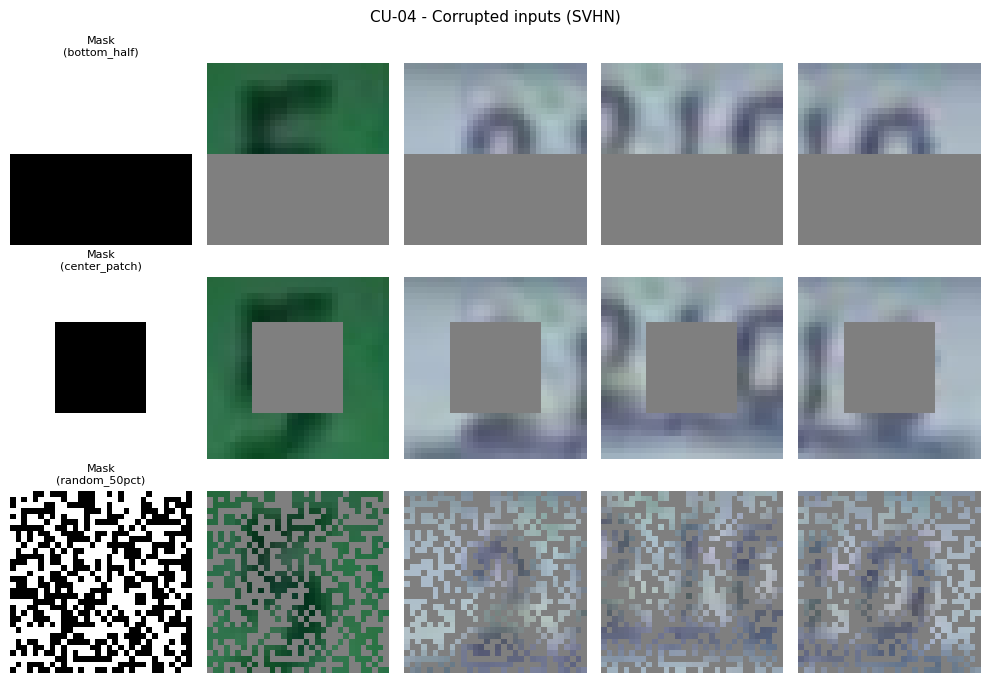

In [ ]:
# 4.1  Test images and three masking strategies
test_dataset = torchvision.datasets.SVHN(
    root='./data', split='test', download=True, transform=transform
)
N_INPAINT = 4
test_imgs  = torch.stack([test_dataset[i][0] for i in range(N_INPAINT)]).to(DEVICE)

H, W = IMG_SIZE, IMG_SIZE

mask_bottom = torch.ones(1, 1, H, W, device=DEVICE)
mask_bottom[:, :, H//2:, :] = 0

mask_center = torch.ones(1, 1, H, W, device=DEVICE)
mask_center[:, :, H//4:3*H//4, W//4:3*W//4] = 0

torch.manual_seed(42)
mask_random = (torch.rand(1, 1, H, W, device=DEVICE) > 0.5).float()

masks = {'bottom_half': mask_bottom, 'center_patch': mask_center, 'random_50pct': mask_random}

fig, axes = plt.subplots(len(masks), N_INPAINT+1, figsize=(10, 7))
for row, (name, mask) in enumerate(masks.items()):
    corr = test_imgs * mask
    axes[row][0].imshow(mask[0,0].cpu().numpy(), cmap='gray')
    axes[row][0].set_title(f'Mask\n({name})', fontsize=8); axes[row][0].axis('off')
    for col in range(N_INPAINT):
        axes[row][col+1].imshow(
            (corr[col].permute(1,2,0).cpu().clamp(-1,1).numpy()*0.5+0.5)
        )
        axes[row][col+1].axis('off')
fig.suptitle('CU-04 - Corrupted inputs (SVHN)', fontsize=11)
plt.tight_layout(); plt.show()

In [ ]:
# 4.2  Inpainting with ImputationSampler (RF-09)
state = torch.load(CKPT_DIR / 'vp_cosine_uncond.pt', map_location=DEVICE)
model.score_model.load_state_dict(state)
model.score_model.eval()

imputer = ImputationSampler(n_resample=1)
inpaint_results = {}

with torch.no_grad():
    for mask_name, mask in masks.items():
        restored = imputer.inpaint(
            score_model=model.score_model, process=vp_process,
            x_known=test_imgs, mask=mask,
            n_steps=500, device=DEVICE,
        )
        inpaint_results[mask_name] = restored
        print(f'Inpainting done: {mask_name}')

Inpainting done: bottom_half
Inpainting done: center_patch
Inpainting done: random_50pct


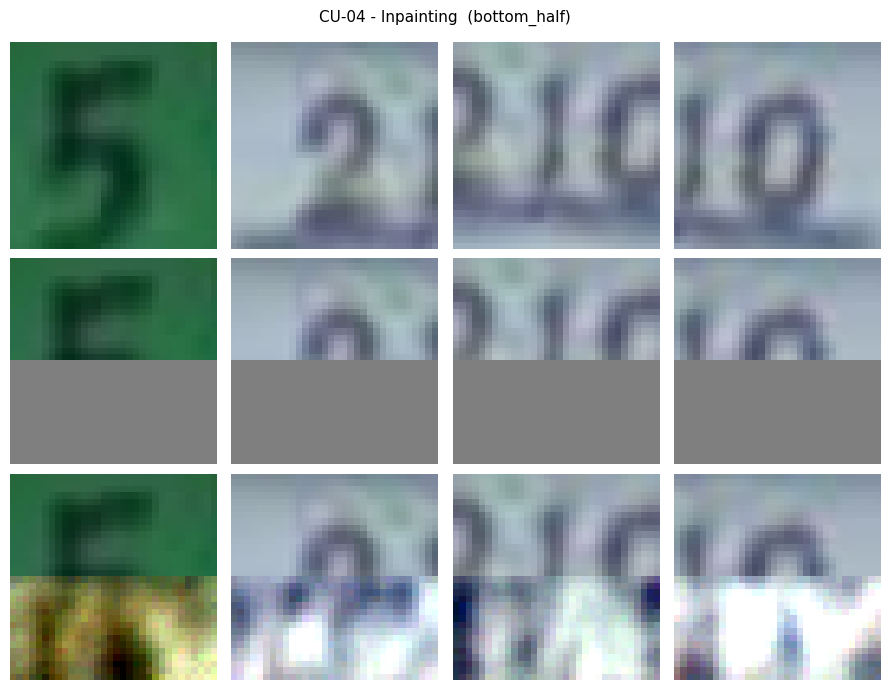

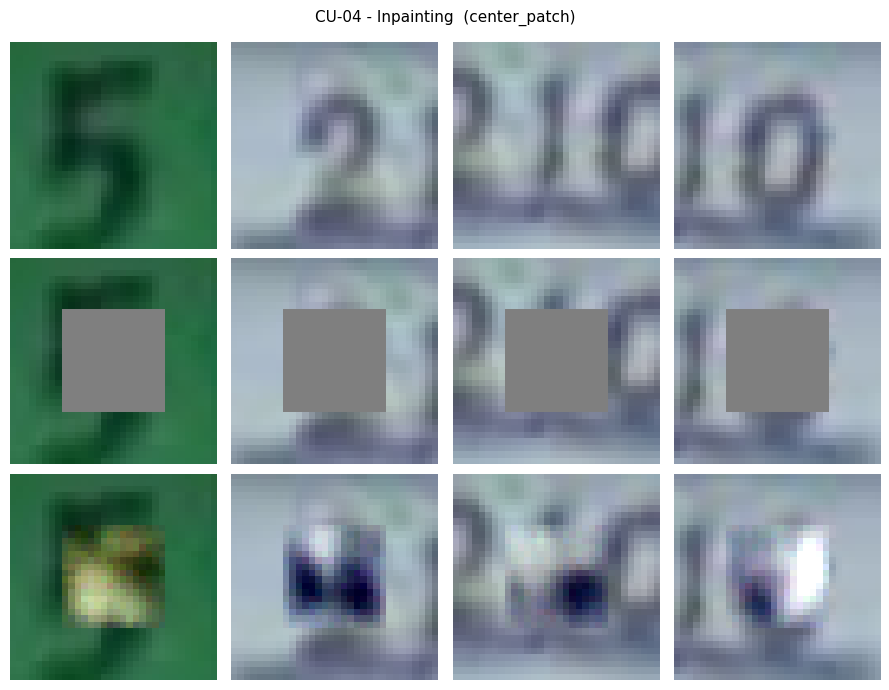

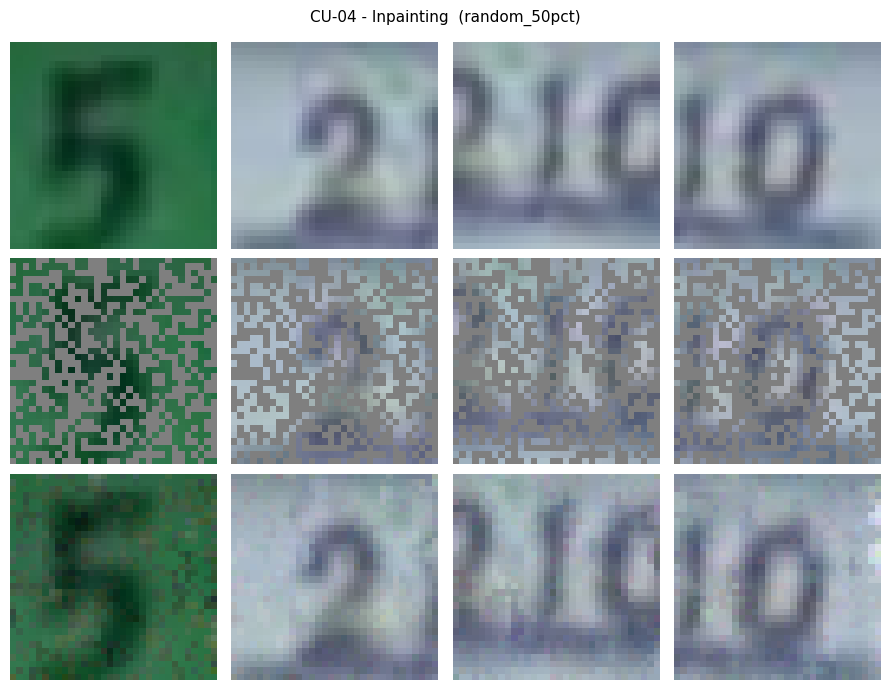

In [ ]:
# 4.3  Visual comparison: original | corrupted | restored
def to_np(t):
    return (t.permute(1,2,0).cpu().clamp(-1,1).numpy()*0.5+0.5)

for mask_name, restored in inpaint_results.items():
    corr = test_imgs * masks[mask_name]
    fig, axes = plt.subplots(3, N_INPAINT, figsize=(9, 7))
    for col in range(N_INPAINT):
        axes[0][col].imshow(to_np(test_imgs[col])); axes[0][col].axis('off')
        axes[1][col].imshow(to_np(corr[col]));      axes[1][col].axis('off')
        axes[2][col].imshow(to_np(restored[col]));  axes[2][col].axis('off')
    for row, lbl in enumerate(['Original', 'Corrupted', 'Restored']):
        axes[row][0].set_ylabel(lbl, fontsize=9, rotation=0, labelpad=45)
    fig.suptitle(f'CU-04 - Inpainting  ({mask_name})', fontsize=11)
    plt.tight_layout(); plt.show()


---
## CU-05 · Quality Evaluation (BPD, FID, IS)

**Goal:** quantitatively assess the model with three complementary metrics (RF-10, RF-11):

| Metric | Formula | Better |
|---|---|---|
| **BPD** | $-\frac{1}{D}\mathbb{E}[\log_2 p(\mathbf{x})]$ | Lower |
| **FID** | $\|\mu_r-\mu_g\|^2 + \mathrm{Tr}(\Sigma_r+\Sigma_g-2(\Sigma_r\Sigma_g)^{1/2})$ | Lower |
| **IS** | $\exp(\mathbb{E}[D_{\mathrm{KL}}(p(y|\mathbf{x})\|p(y))])$ | Higher |

DDPM reference on CIFAR-10: **FID~3.17 | IS~9.46 | BPD~3.75**


In [ ]:
# 5.1  Metric methods (RF-10, RF-11)
#   model.compute_bpd(x_0, n_steps)          → Tensor[B]   bits-per-dim
#   model.compute_fid(real, fake, batch_size) → float        FID
#   model.compute_is(images, n_splits)        → (mean, std)  Inception Score

state = torch.load(CKPT_DIR / 'vp_cosine_uncond.pt', map_location=DEVICE)
model.score_model.load_state_dict(state)
model.score_model.eval()
print('Score model loaded for evaluation.')

Score model loaded for evaluation.


In [ ]:
# 5.2  Bits Per Dimension  (RF-10)
# NOTE: compute_bpd uses torch.autograd.grad internally (Hutchinson trace);
#       it must NOT run inside torch.no_grad().
bpd_subset = torch.utils.data.Subset(test_dataset, range(256))
bpd_loader = torch.utils.data.DataLoader(bpd_subset, batch_size=32)

bpd_values = []
for x, _ in bpd_loader:
    bpd_values.append(model.compute_bpd(x, n_steps=100))

bpd_value = torch.cat(bpd_values).mean().item()
print(f'BPD = {bpd_value:.4f} bits/dim  (DDPM reference: ~3.75)')


BPD = -3.5357 bits/dim  (DDPM reference: ~3.75)


In [ ]:
# 5.3  Generate batch for FID / IS  (increase N_EVAL to 10000 for publications)
N_EVAL = 1000;  N_REAL = 1000;  EVAL_BATCH = 50

em_eval  = EulerMaruyamaSampler()
gen_imgs = []

with torch.no_grad():
    for _ in range(N_EVAL // EVAL_BATCH):
        gen_imgs.append(
            em_eval.sample(
                score_model=model.score_model, process=vp_process,
                n_images=EVAL_BATCH, img_shape=(CHANNELS, IMG_SIZE, IMG_SIZE),
                n_steps=500, device=DEVICE,
            ).cpu()
        )

gen_imgs  = torch.cat(gen_imgs, dim=0)
real_imgs = torch.stack([test_dataset[i][0] for i in range(N_REAL)])
print(f'Generated: {gen_imgs.shape[0]}  |  Real: {real_imgs.shape[0]}')

KeyboardInterrupt: 

In [ ]:
# 5.4  Compute FID and IS  (RF-11)
gen01  = (gen_imgs.clamp(-1,1)*0.5+0.5)
real01 = (real_imgs.clamp(-1,1)*0.5+0.5)

fid        = model.compute_fid(real01, gen01)
is_m, is_s = model.compute_is(gen01, n_splits=10)

print('-'*45)
print(f'  FID  = {fid:.2f}          (lower is better)')
print(f'  IS   = {is_m:.2f} +/- {is_s:.2f}   (higher is better)')
print(f'  BPD  = {bpd_value:.4f}      (lower is better)')
print('-'*45)
print('DDPM reference:  FID~3.17  IS~9.46  BPD~3.75')

In [ ]:
# 5.5  Sampler benchmark: compare all three samplers
samplers_bench = {
    'Euler-Maruyama'      : EulerMaruyamaSampler(),
    'Predictor-Corrector' : PredictorCorrectorSampler(n_corrector_steps=1, snr=0.16),
    'Probability Flow ODE': ProbabilityFlowODESampler(),
}

bench_results = {}
for name, sampler in samplers_bench.items():
    print(f'Evaluating {name} ...')
    batches = []
    with torch.no_grad():
        for _ in range(N_EVAL // EVAL_BATCH):
            batches.append(
                sampler.sample(
                    score_model=model.score_model, process=vp_process,
                    n_images=EVAL_BATCH, img_shape=(CHANNELS, IMG_SIZE, IMG_SIZE),
                    n_steps=500, device=DEVICE,
                ).cpu()
            )
    g01          = (torch.cat(batches, 0).clamp(-1,1)*0.5+0.5)
    fid_b        = model.compute_fid(real01, g01)
    is_mb, is_sb = model.compute_is(g01, n_splits=10)
    bench_results[name] = {'FID': fid_b, 'IS_mean': is_mb, 'IS_std': is_sb}
    print(f'  FID={fid_b:.2f}  IS={is_mb:.2f}+/-{is_sb:.2f}')

In [ ]:
# 5.6  Bar chart: metric comparison
names  = list(bench_results.keys())
fids   = [bench_results[n]['FID']     for n in names]
is_ms  = [bench_results[n]['IS_mean'] for n in names]
is_ss  = [bench_results[n]['IS_std']  for n in names]
colors = ['steelblue', 'seagreen', 'firebrick']
x      = np.arange(len(names))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(x, fids, color=colors, alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=12, ha='right', fontsize=9)
axes[0].set_ylabel('FID  (lower = better)'); axes[0].set_title('Frechet Inception Distance')
axes[0].axhline(3.17, ls='--', color='black', lw=1, label='DDPM ref'); axes[0].legend(fontsize=8)

axes[1].bar(x, is_ms, yerr=is_ss, color=colors, alpha=0.85, capsize=5)
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=12, ha='right', fontsize=9)
axes[1].set_ylabel('IS  (higher = better)'); axes[1].set_title('Inception Score')
axes[1].axhline(9.46, ls='--', color='black', lw=1, label='DDPM ref'); axes[1].legend(fontsize=8)

fig.suptitle('CU-05 - Sampler benchmark (SVHN)', fontsize=12)
plt.tight_layout(); plt.show()

---
## Summary

| Use Case | Key API | What was shown |
|---|---|---|
| **CU-01** Training | `DiffusionModel.compute_loss()`, `VEProcess`/`VPProcess` | VE/VP setup, forward visualisation, loss curve |
| **CU-02** Unconditional gen. | `EulerMaruyamaSampler`, `PredictorCorrectorSampler`, `ProbabilityFlowODESampler` | 3-sampler visual comparison |
| **CU-03** Conditional (CFG) | `ConditionalUNet`, `CFGWrapper` | Per-class synthesis; guidance scale sweep |
| **CU-04** Inpainting | `ImputationSampler.inpaint()` | 3 mask types; original/corrupted/restored |
| **CU-05** Quality metrics | `model.compute_bpd()`, `model.compute_fid()`, `model.compute_is()` | BPD, FID, IS; sampler benchmark vs DDPM |

**For production quality:** 500+ training epochs; 10 000+ images for FID; `heun` ODE solver for BPD.

---
